In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a Word2Vec model
print("Training Word2Vec model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a Word2Vec embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(word2vec_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = word2vec_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of Word2Vec indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['word2vec_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['word2vec_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with Word2Vec embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep Word2Vec embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the GRU model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Save the trained GRU model
model_path = r"C:\Users\PC\Downloads\GRU_model_word2vec.h5"  # File path to save the model
model.save(model_path)
print(f"Trained GRU model saved to {model_path}")

# Step 9: Classification Report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Training Word2Vec model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
Epoch 1/5
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 213s 45ms/step - accuracy: 0.8812 - loss: 0.2818 - val_accuracy: 0.9454 - val_loss: 0.1460
Epoch 2/5
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 224s 37ms/step - accuracy: 0.9506 - loss: 0.1305 - val_accuracy: 0.9556 - val_loss: 0.1170
Epoch 3/5
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 170s 37ms/step - accuracy: 0.9611 - loss: 0.1032 - val_accuracy: 0.9578 - val_loss: 0.1113
Epoch 4/5
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 186s 40ms/step - accuracy: 0.9657 - loss: 0.0900 - val_accuracy: 0.9599 - val_loss: 0.1096
Epoch 5/5
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 168s 36ms/step - accuracy: 0.9707 - loss: 0.0787 - val_accuracy: 0.9589 - val_loss: 0.1128
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9604 - loss: 0.1067


GRU Test Accuracy: 96.14%
Trained GRU model saved to C:\Users\PC\Downloads\GRU_model_word2vec.h5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     23238
           1       0.97      0.95      0.96     23171

    accuracy                           0.96     46409
   macro avg       0.96      0.96      0.96     46409
weighted avg       0.96      0.96      0.96     46409

Accuracy: 0.96
Precision: 0.97
Recall: 0.95
F1 Score: 0.96


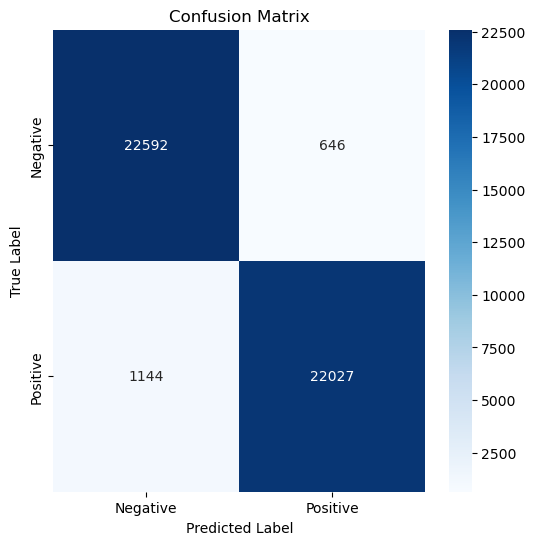

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 10: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 11: Plot the confusion matrix using Seaborn
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step
AUC: 0.99


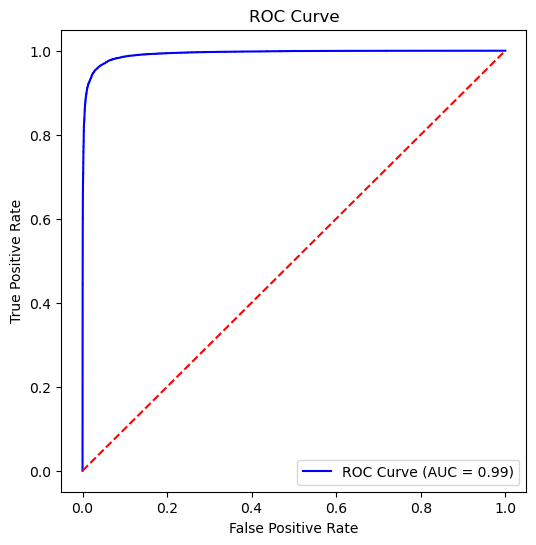

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 12: Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))

# Step 13: Compute the AUC score
auc = roc_auc_score(y_test, model.predict(X_test))
print(f"AUC: {auc:.2f}")

# Step 14: Plot the ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Step 15: Compute Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Squared Error (MSE): 0.04
Mean Absolute Error (MAE): 0.04
Root Mean Squared Error (RMSE): 0.20


Mean Squared Error (MSE): 0.04
Mean Absolute Error (MAE): 0.04
Root Mean Squared Error (RMSE): 0.20


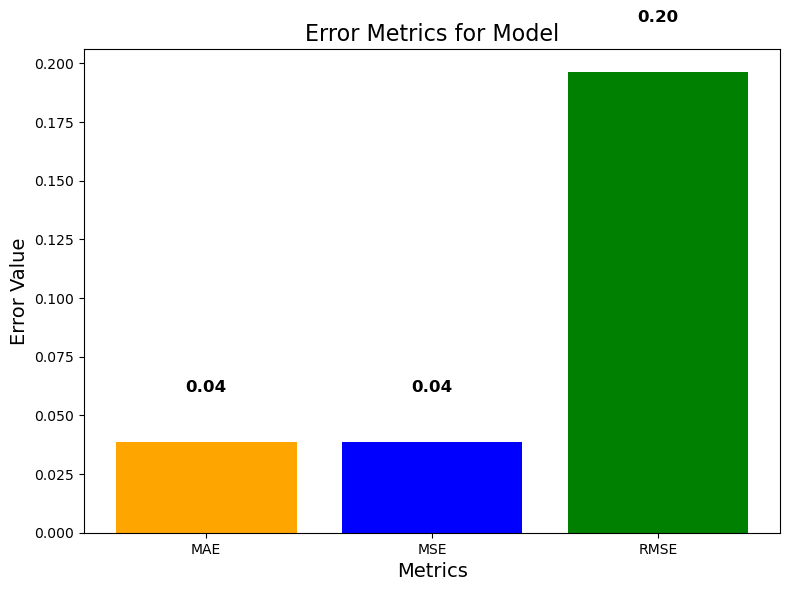

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Compute Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print error metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Visualization of error metrics
error_metrics = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse
}

# Set colors for the bars
colors = ['orange', 'blue', 'green']

# Create a bar plot for the error metrics
plt.figure(figsize=(8, 6))
bars = plt.bar(error_metrics.keys(), error_metrics.values(), color=colors)

# Add labels on the left corner of each bar
for bar, value in zip(bars, error_metrics.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{value:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add title and labels
plt.title('Error Metrics for Model', fontsize=16)
plt.ylabel('Error Value', fontsize=14)
plt.xlabel('Metrics', fontsize=14)
plt.tight_layout()

# Show plot
plt.show()


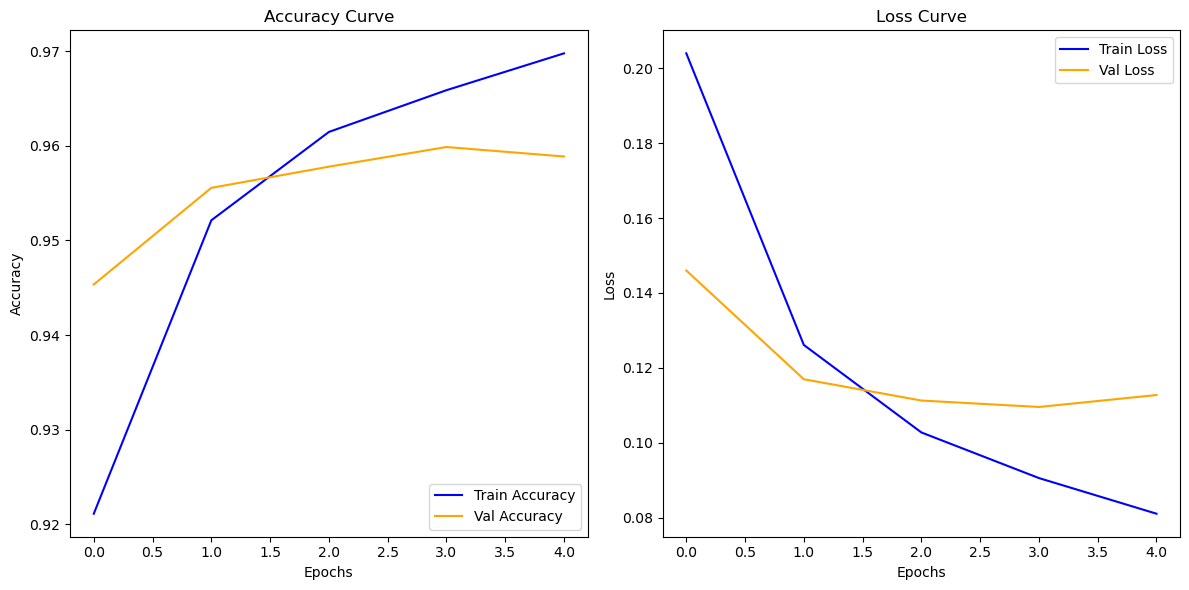

In [7]:
import matplotlib.pyplot as plt

# Assuming you have the history object from model training
# Example: history = model.fit(...)

# Accuracy curve
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
